# CAPM Project
## 1. Project Objective
The goal of this project is to estimate the market beta of 10 selected stocks in different sectors using the Capital Asset Pricing Model using data from 2010-01-01 to 2026-05-11. We will use a rolling window of 6 months to calculate beta in each different periods for different stocks.

The selected stocks are:
1. Information Technology: Apple Inc. (AAPL)
2. Health Care: UnitedHealth Group (UNH)
3. Financials: JPMorgan Chase & Co. (JPM)
4. Communication Services: Alphabet Inc. (GOOGL)
5. Consumer Discretionary: Amazon.com Inc. (AMZN)
6. Industrials: Union Pacific Corp. (UNP)
7. Consumer Staples: Procter & Gamble Co. (PG)
8. Energy: ExxonMobil Corp. (XOM)
9. Utilities: NextEra Energy Inc. (NEE)
10. Materials: Linde PLC (LIN)

## 2. Data Sources
Stock prices are downloaded from Yahoo Finance using the yfinance Python package.
## 3. Methodology
We calculate excess returns and run linear regressions of each stock's excess return against the market's excess return.
## 4. Results
This section will include beta estimates, alpha estimates, charts, and analysis of the trends of change of these values.
## 5. Conclusion
This section summarizes the main findings and limitations.

First load all the packages needed for analysis:

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

Now define the stocks, market index,risk free symbol, start day, end day, and the rolling window

In [2]:
stocks=["AAPL","UNH","JPM","GOOGL","AMZN","UNP","PG","XOM","NEE","LIN"]
market="SPY"
risk_free_symbol = '^IRX'
start_date="2010-01-01"
end_date="2026-05-11"
window=126 #representing 6 months of trading days

start_date, end_date

('2010-01-01', '2026-05-11')

In [3]:
# Get the daily stock return and daily market return
stock_data=yf.download(stocks, start=start_date, end=end_date,auto_adjust=True)['Close']
market_data=yf.download(market, start=start_date, end=end_date,auto_adjust=True)['Close']
stock_return=stock_data.pct_change().dropna()
market_return=market_data.pct_change().dropna()
stock_return.head(), market_return.head()

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed


(Ticker          AAPL      AMZN     GOOGL       JPM       LIN       NEE  \
 Date                                                                     
 2010-01-05  0.001729  0.005900 -0.004404  0.019370 -0.018636 -0.009765   
 2010-01-06 -0.015906 -0.018116 -0.025209  0.005495  0.008871  0.009861   
 2010-01-07 -0.001849 -0.017013 -0.023280  0.019809  0.002601 -0.002817   
 2010-01-08  0.006648  0.027077  0.013331 -0.002456  0.006546 -0.008663   
 2010-01-11 -0.008822 -0.024041 -0.001512 -0.003357  0.009449 -0.000760   
 
 Ticker            PG       UNH       UNP       XOM  
 Date                                                
 2010-01-05  0.000327 -0.001586  0.013917  0.003905  
 2010-01-06 -0.004743  0.009848  0.001508  0.008643  
 2010-01-07 -0.005423  0.038377 -0.008886 -0.003142  
 2010-01-08 -0.001322 -0.009391  0.033886 -0.004012  
 2010-01-11 -0.003970  0.006728 -0.006614  0.011220  ,
 Ticker           SPY
 Date                
 2010-01-05  0.002647
 2010-01-06  0.000704
 2010-

In [4]:
# To get the risk free rate
risk_free_data = yf.download(risk_free_symbol, start=start_date, end=end_date)['Close']
risk_free_rate = risk_free_data/100/252  # Convert to daily risk-free rate
risk_free_rate.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^IRX
Date,
2010-01-04,0.000002
2010-01-05,0.000002
2010-01-06,0.000002
2010-01-07,0.000002
2010-01-08,0.000002


In [5]:
# Before proceeding with the CAPM regresion analysis, we need to align the data by date and calculate the excess returns for both the stocks and the market.
# Align the data by date
data = pd.concat([stock_return, market_return, risk_free_rate], axis=1).dropna()
data.columns = list(stock_return.columns) + ['Market_Return', 'Risk_Free_Rate']
# Write the data into data folder:
# data.to_csv('../data/capm_data.csv')
data.head()


,AAPL,AMZN,GOOGL,JPM,LIN,NEE,PG,UNH,UNP,XOM,Market_Return,Risk_Free_Rate
Date,,,,,,,,,,,,
2010-01-05,0.001729,0.005900,-0.004404,0.019370,-0.018636,-0.009765,0.000327,-0.001586,0.013917,0.003905,0.002647,2.380952e-06
2010-01-06,-0.015906,-0.018116,-0.025209,0.005495,0.008871,0.009861,-0.004743,0.009848,0.001508,0.008643,0.000704,1.785714e-06
2010-01-07,-0.001849,-0.017013,-0.023280,0.019809,0.002601,-0.002817,-0.005423,0.038377,-0.008886,-0.003142,0.004222,1.785714e-06
2010-01-08,0.006648,0.027077,0.013331,-0.002456,0.006546,-0.008663,-0.001322,-0.009391,0.033886,-0.004012,0.003327,1.587302e-06
2010-01-11,-0.008822,-0.024041,-0.001512,-0.003357,0.009449,-0.000760,-0.003970,0.006728,-0.006614,0.011220,0.001397,9.920635e-07


## Run True Rolling 6-Month CAPM Regressions

For each day after the first 126 trading days, run a CAPM regression on the previous 126 observations:

$$R_i - R_f = \alpha + \beta (R_m - R_f) + \epsilon$$

In [6]:
data['Excess_Market_Return'] = data['Market_Return'] - data['Risk_Free_Rate']
for stock in stocks:
    data[f'Excess_{stock}_Return'] = data[stock] - data['Risk_Free_Rate']

# Run rolling CAPM regressions over a 6-month trading day window:
rolling_results = []
for end_idx in range(window,len(data)):
    start_idx=end_idx - window
    window_data = data.iloc[start_idx:end_idx].copy()
    for stock in stocks:
        model=smf.ols(f'Excess_{stock}_Return ~ Excess_Market_Return', data=window_data).fit()
        rolling_results.append({'Date':window_data.index[-1], 
                                "Stock":stock, 
                                'Alpha':model.params['Intercept'], 
                                'Beta':model.params['Excess_Market_Return'], 
                                'R_squared':model.rsquared,"p_value":model.pvalues["Excess_Market_Return"]})
rolling_results=pd.DataFrame(rolling_results).set_index("Date")
rolling_results.head()


,Stock,Alpha,Beta,R_squared,p_value
Date,,,,,
2010-07-06,AAPL,0.002105,1.161168,0.548226,3.865611e-23
2010-07-06,UNH,-0.000090,0.671066,0.239110,6.260863e-09
2010-07-06,JPM,-0.000274,1.303021,0.652256,3.187239e-30
2010-07-06,GOOGL,-0.002190,0.875243,0.426609,1.144927e-16
2010-07-06,AMZN,-0.000676,1.028578,0.349361,3.188599e-13


In [7]:
# Write the rolling result into output:
# rolling_results.to_csv("../outputs/roll_results.csv")


# Analyze CAPM Model for each stock:

## First, take a look at the summary table:


In [8]:
summary=rolling_results.groupby("Stock")[['Alpha','Beta']].agg(["mean","max","min"])
summary

Alpha                          Beta                    
           mean       max       min      mean       max       min
Stock                                                            
AAPL   0.000436  0.003758 -0.004550  1.113715  1.713788  0.222813
AMZN   0.000409  0.004465 -0.003300  1.294481  2.288099  0.534813
GOOGL  0.000288  0.003904 -0.002356  1.158370  1.820894  0.700037
JPM    0.000083  0.002974 -0.002831  1.138769  1.902925  0.440126
LIN    0.000098  0.001856 -0.001999  0.857389  1.430972  0.047249
NEE    0.000389  0.002926 -0.003772  0.509394  1.130232 -0.209976
PG     0.000105  0.002312 -0.001884  0.448566  0.926183 -0.441938
UNH    0.000351  0.002891 -0.006004  0.754694  1.476467 -0.067231
UNP    0.000098  0.002527 -0.002271  0.987074  1.537390  0.372228
XOM   -0.000018  0.004746 -0.004179  0.778219  1.409972 -0.525005

## Interpretation:
First, the alpha we calculated is for daily. Therefore, to make it more sensible, we should convert it to annual alpha (daily alpha * 252).

One thing we notice is that, the average alpha for all stocks except XOM is positive. This suggests that, on average, these stocks generated returns above what CAPM would predict, after controlling for the market risk. 

In addition, all stocks have a negative minimum beta value. This means that, at some point in the sample, each stock experienced at least one 6-month period in which its returns moved in the opposite direction of the market, on average. This could be due to each company's idiosyncratic risk.

AAPL, AMZN, GOOGL, JPM have mean beta values to be greater than 1, which meets our intuition as these stocks are either in Tech or Financial sector, which are sensitive to market changes usually. In contrast, defensive stocks NEE and PG 
all have beta values around 0.4-0.5, which fits our expectation that defensive stocks should have a relatively low beta.

# Next step: Beta and Alpha trends over time for each stock


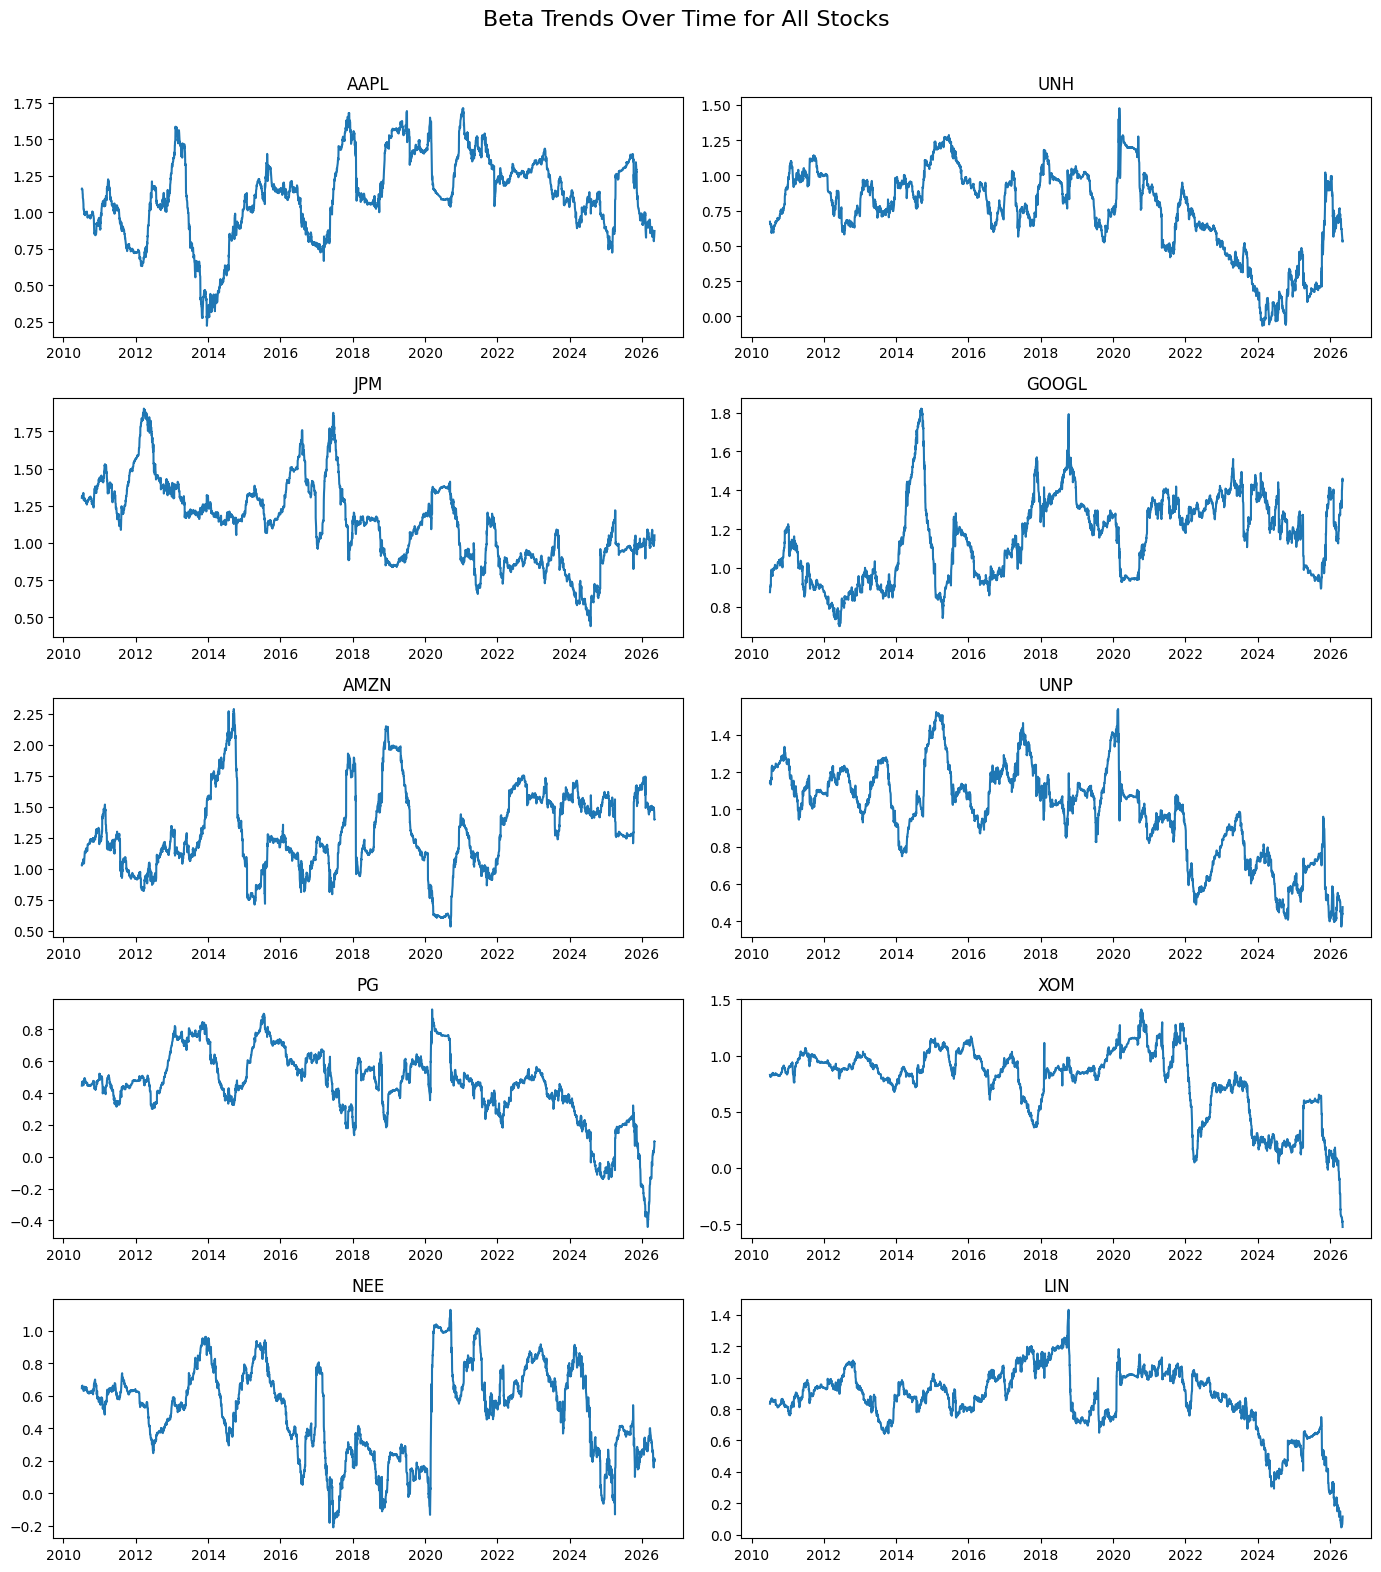

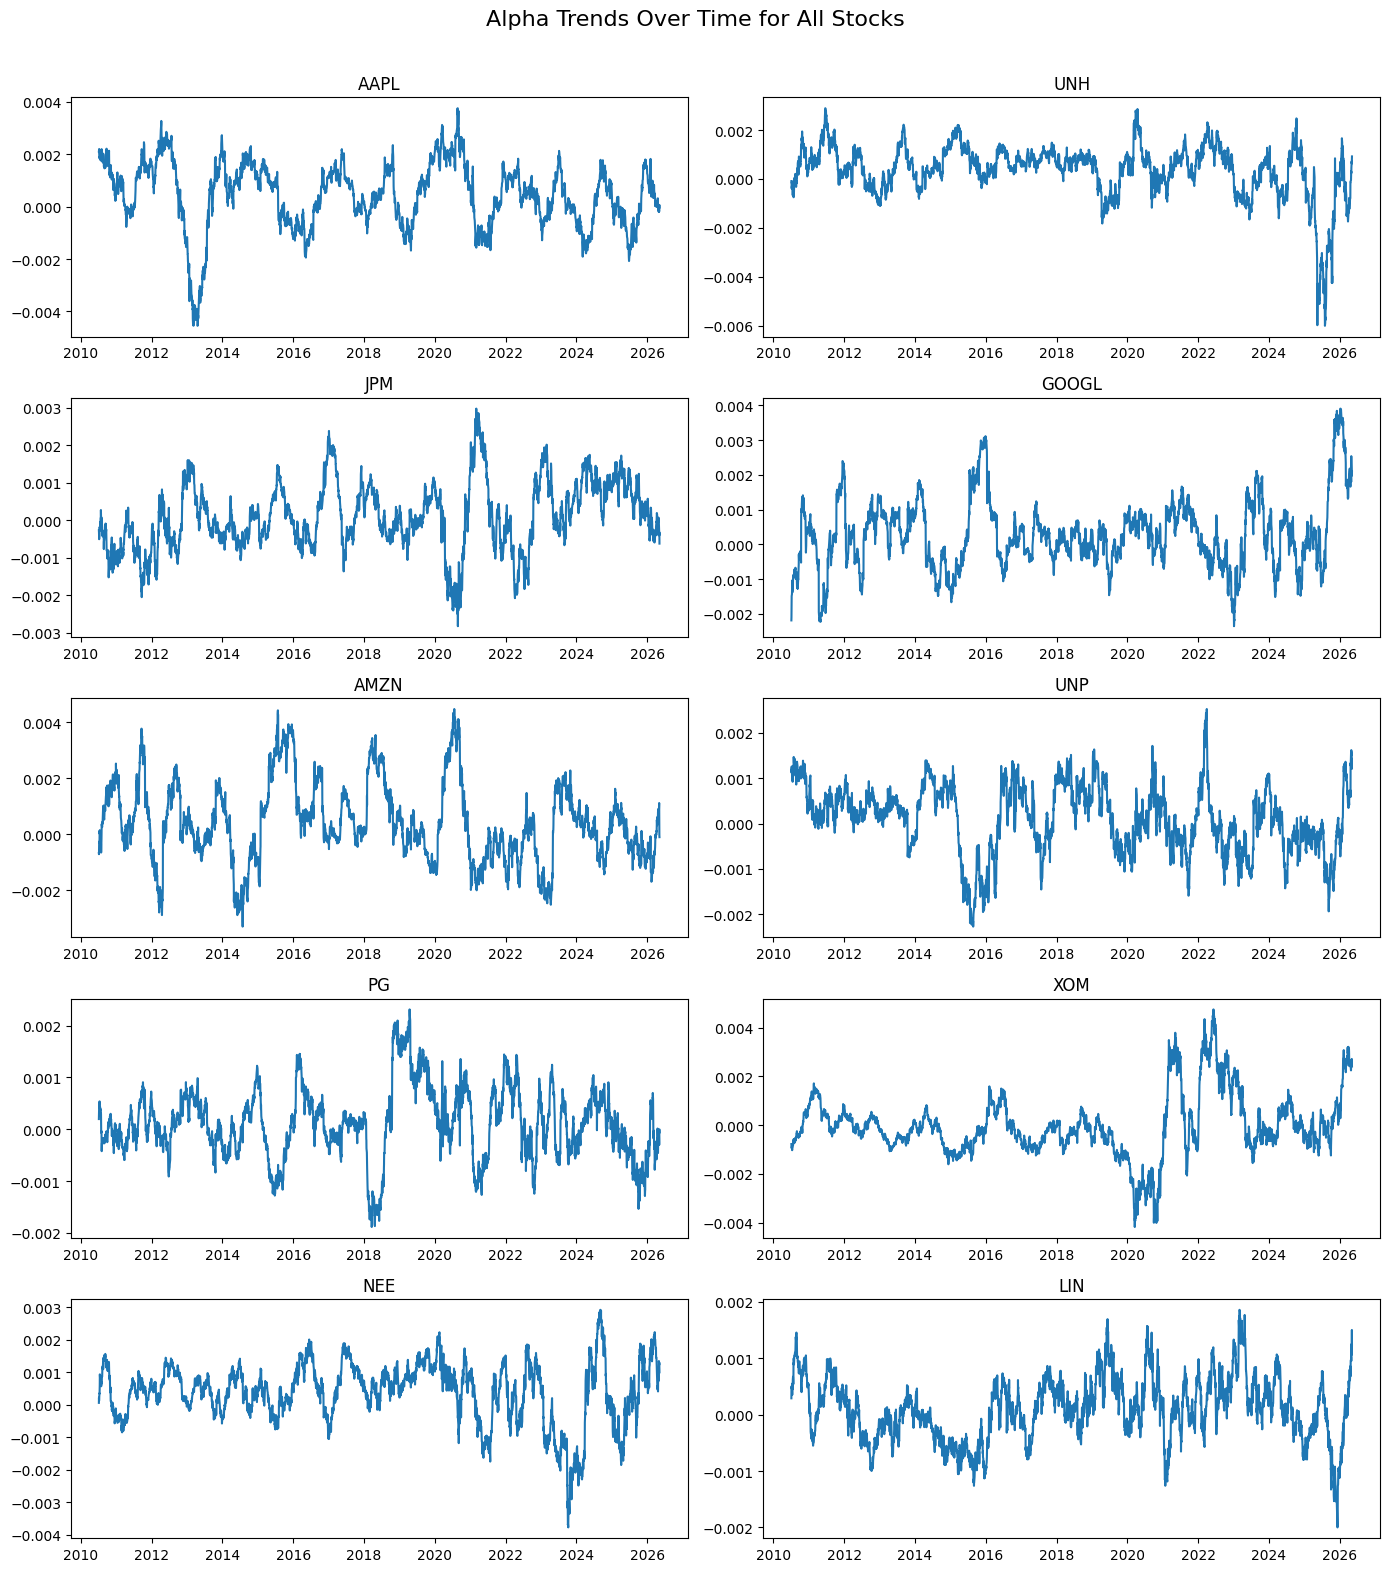

In [9]:
#Plot Beta and Alpha for each stocks against time
fig,axes=plt.subplots(5,2,figsize=(14,16))
fig.suptitle("Beta Trends Over Time for All Stocks", fontsize=16)
axes=axes.flatten()
for i, stock in enumerate(stocks):
    ax=axes[i]
    subset=rolling_results[rolling_results["Stock"]==stock]
    ax.plot(subset.index,subset["Beta"])
    ax.set_title(stock)
plt.tight_layout(rect=[0, 0, 1, 0.97])

fig,axes=plt.subplots(5,2,figsize=(14,16))
fig.suptitle("Alpha Trends Over Time for All Stocks", fontsize=16)
axes=axes.flatten()
for i, stock in enumerate(stocks):
    ax=axes[i]
    subset=rolling_results[rolling_results["Stock"]==stock]
    ax.plot(subset.index,subset["Alpha"])
    ax.set_title(stock)
plt.tight_layout(rect=[0, 0, 1, 0.97])


# Interpretation:

## Beta
Overall, the rolling CAPM analysis shows that beta varies over time across all 10 stocks, but the general patterns are broadly consistent with economic intuition. Growth-oriented technology and consumer discretionary firms such as AAPL, AMZN, and GOOGL tend to have betas greater than 1 in many periods, indicating that they are generally more sensitive to market movements than the overall market. By contrast, more defensive firms such as PG and NEE tend to have lower betas on average, suggesting lower market sensitivity.

In addition, XOM warrants further exploration because its beta declined from around 1.0 to negative values beginning in 2025. One possible explanation is that this reflects a temporary divergence rather than a permanent structural change. Geopolitical tensions may have placed downward pressure on the energy sector even as the broader market continued to rise, causing XOM’s returns to move differently from overall market returns during that period.

Another interesting finding is that many stocks’ beta estimates appear to be non-stationary over time, indicating a dynamic pattern in how these stocks respond to market movements. Rather than remaining fixed, beta changes across periods, suggesting that companies’ exposure to systematic risk evolves over time.

## Alpha:
From the graph, the alpha of each stock appears to show a mean-reverting pattern around 0, which is consistent with the CAPM framework. From a market efficiency perspective, this makes sense because abnormal returns are not expected to persist over time, so alpha should fluctuate around zero rather than remain consistently positive or negative.

## Next Step:
It may be interesting to check how the beta value for each stock moves concurrently with other stocks' beta. To do this, I want to first create a plot with all stock's beta plotting in the same graph and then use correlation table to check each pair's correlation.



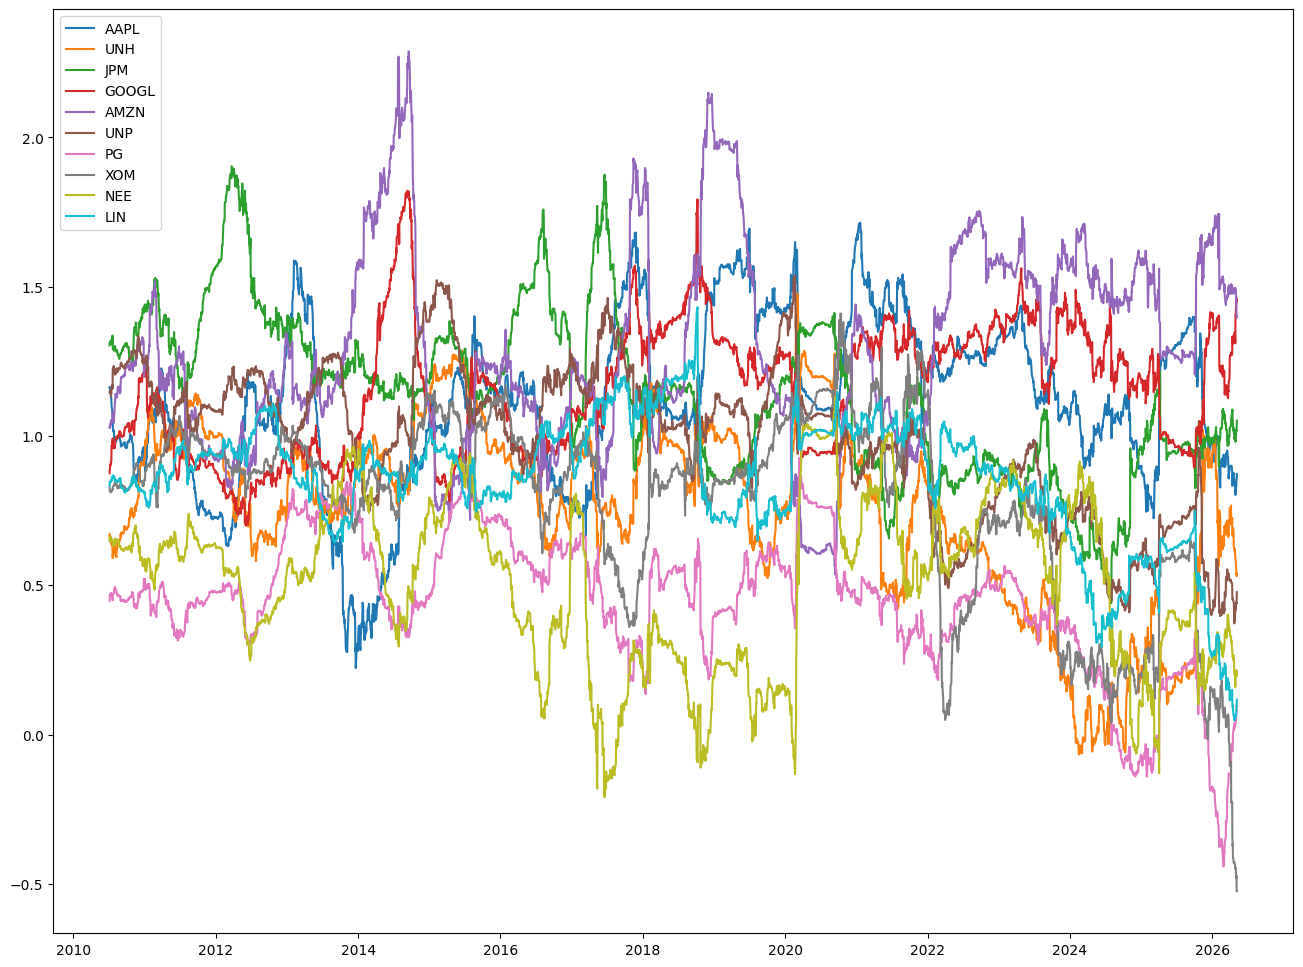

In [10]:
#Plot the beta together in one graph
plt.figure(figsize=(16,12))
for stock in stocks:
    subset=rolling_results[rolling_results['Stock']==stock]
    plt.plot(subset.index,subset["Beta"],label=stock)
plt.legend()
plt.show()

We can see like NEE's and PG's beta seem to be moving together, and a correlation table will help us better uncover the pattern for each pair:

In [11]:
# Constructing a correlation table
beta_table=rolling_results.pivot(columns='Stock',values='Beta')
beta_table.corr()

Stock,AAPL,AMZN,GOOGL,JPM,LIN,NEE,PG,UNH,UNP,XOM
Stock,,,,,,,,,,
AAPL,1.000000,0.043299,0.259976,-0.332971,0.137472,-0.187932,-0.040979,-0.076877,-0.002469,0.092009
AMZN,0.043299,1.000000,0.676777,-0.574137,-0.370043,-0.223425,-0.425942,-0.305177,-0.458124,-0.490410
GOOGL,0.259976,0.676777,1.000000,-0.623041,-0.059052,-0.184559,-0.340187,-0.231291,-0.349525,-0.302004
JPM,-0.332971,-0.574137,-0.623041,1.000000,0.442270,-0.111992,0.413094,0.545614,0.625751,0.472836
LIN,0.137472,-0.370043,-0.059052,0.442270,1.000000,0.060575,0.527338,0.485477,0.546165,0.624932
NEE,-0.187932,-0.223425,-0.184559,-0.111992,0.060575,1.000000,0.443490,0.131065,0.009324,0.274849
PG,-0.040979,-0.425942,-0.340187,0.413094,0.527338,0.443490,1.000000,0.539242,0.611500,0.701761
UNH,-0.076877,-0.305177,-0.231291,0.545614,0.485477,0.131065,0.539242,1.000000,0.578239,0.639956
UNP,-0.002469,-0.458124,-0.349525,0.625751,0.546165,0.009324,0.611500,0.578239,1.000000,0.690794


# Interpretation
Several stocks show strong positive/negative correlation of their beta values, which means the market reacts similiarly/oppositely with these stocks respectively with the market return.

# Model Diagnostic/Goodness of fit
## R-Square
Below we will examine the CAPM(linear model)'s goodness of fit for each stock across different times. 

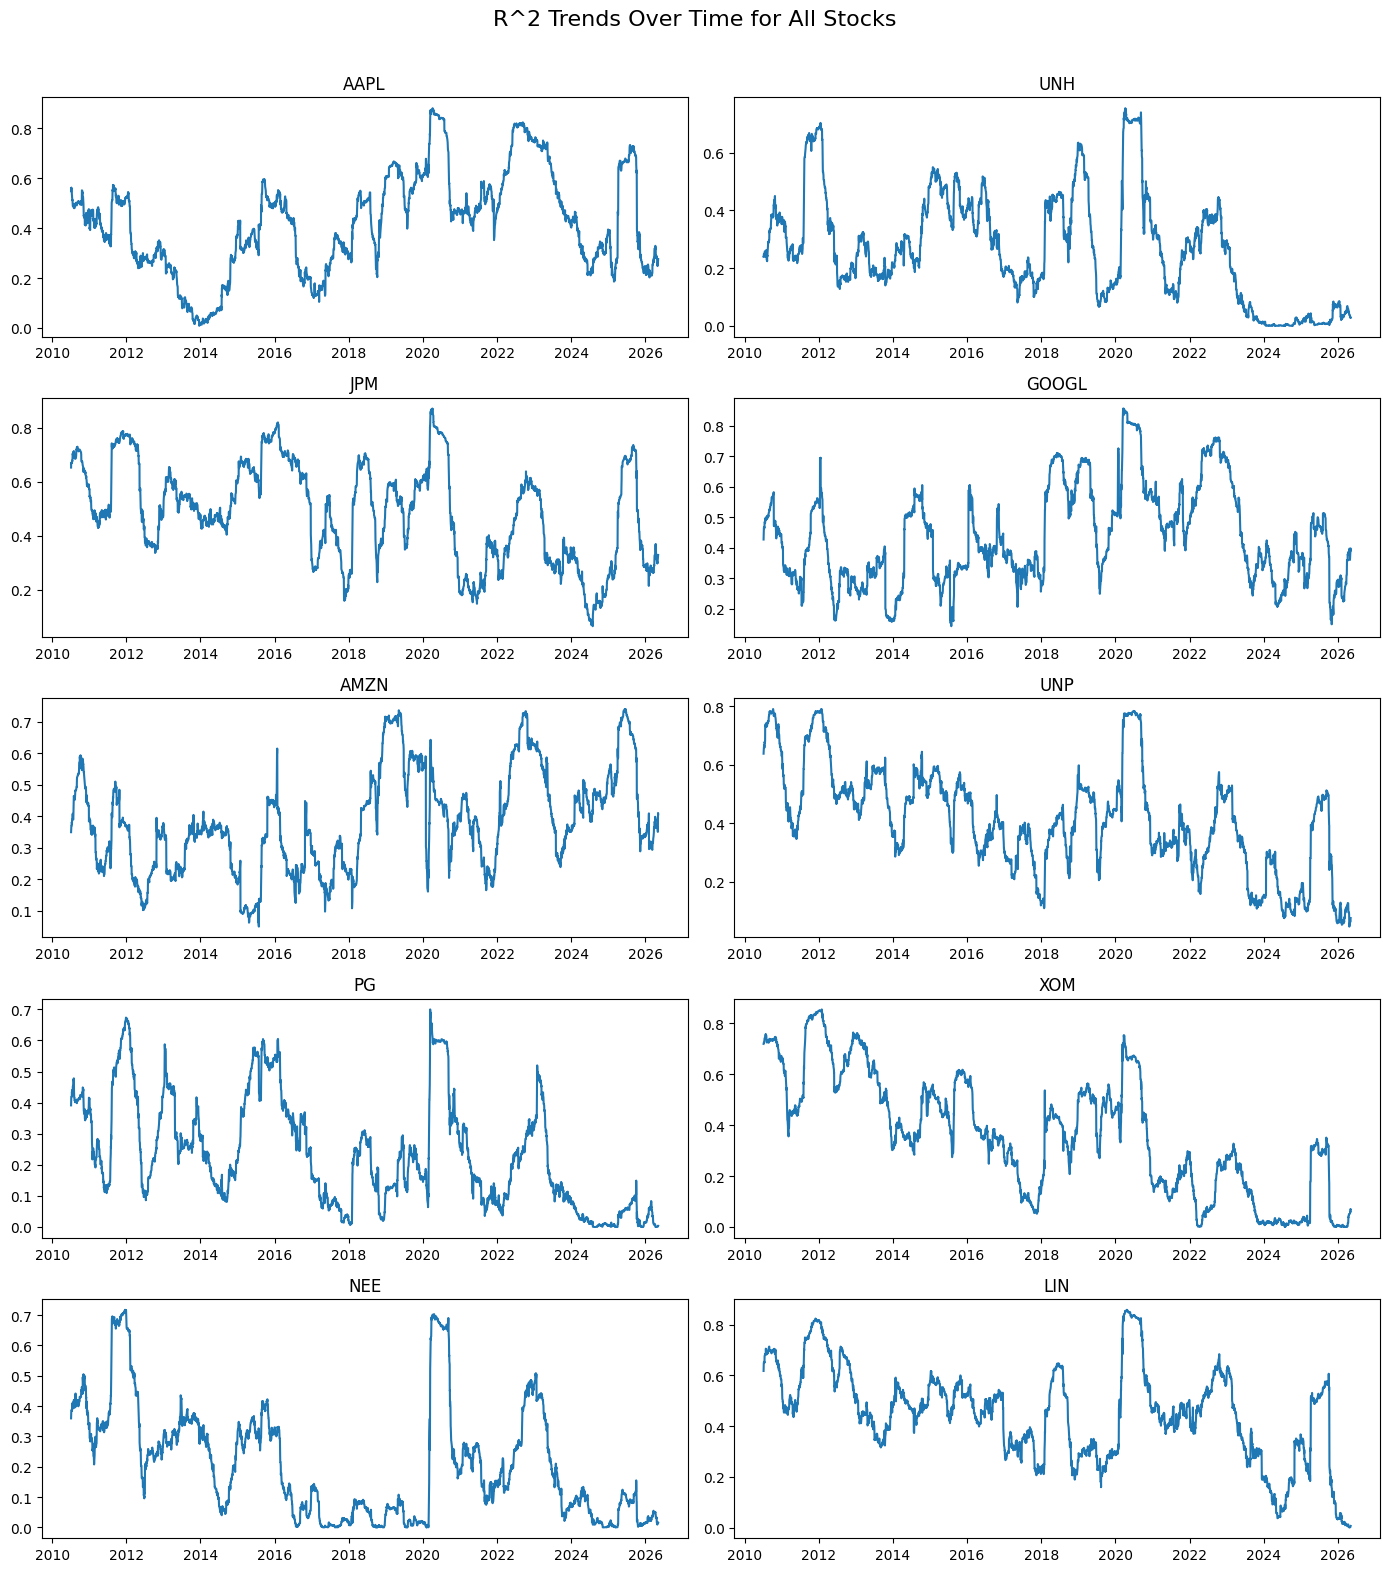

In [12]:
#plot R^2 trends:
fig,axes=plt.subplots(5,2,figsize=(14,16))
fig.suptitle("R^2 Trends Over Time for All Stocks", fontsize=16)
axes=axes.flatten()
for i, stock in enumerate(stocks):
    ax=axes[i]
    subset=rolling_results[rolling_results['Stock']==stock]
    ax.plot(subset.index,subset['R_squared'])
    ax.set_title(stock)
plt.tight_layout(rect=[0, 0, 1, 0.97])

Notice that the R-squared values differ substantially across stocks and across time periods. This suggests that the simple CAPM model does not explain each stock's excess return equally well in every period. For some stocks and in some windows, the model fits the data relatively well, while in others its explanatory power is much weaker.

Another interesting pattern is that the R-squared series across stocks appear to have a similar shape over time: they often rise and fall together. This may indicate that there are market-wide periods in which the CAPM performs better or worse for many stocks simultaneously. In other words, the model's goodness of fit seems to be influenced not only by stock-specific characteristics but also by broader market conditions.

# Residuals Normality Testing
Below I test the residual normality assumption for each stock in each rolling period using the Shapiro-Wilk test. I track both the Shapiro-Wilk test statistic and the p-value over time.

In [13]:
alpha = 0.05

normality_results = []

for end_idx in range(window, len(data)):
    start_idx = end_idx - window
    window_data = data.iloc[start_idx:end_idx].copy()
    end_date = window_data.index[-1]

    for stock in stocks:
        model = smf.ols(
            f'Excess_{stock}_Return ~ Excess_Market_Return',
            data=window_data
        ).fit()
        shapiro_stat, shapiro_p = stats.shapiro(model.resid)

        normality_results.append({
            'Date': end_date,
            'Stock': stock,
            'Shapiro_stat': shapiro_stat,
            'Shapiro_p_value': shapiro_p,
            'Shapiro_p_critical_5pct': alpha,
            'Reject_Shapiro_5pct': shapiro_p < alpha
        })

normality_results = pd.DataFrame(normality_results).set_index('Date')

normality_summary = (
    normality_results.groupby('Stock')
    .agg(
        windows=('Shapiro_p_value', 'size'),
        mean_shapiro_p=('Shapiro_p_value', 'mean'),
        shapiro_reject_rate=('Reject_Shapiro_5pct', 'mean')
    )
)

normality_summary['shapiro_reject_rate'] *= 100
normality_summary = normality_summary.sort_values('shapiro_reject_rate', ascending=False)

display(normality_summary.round(3))

print(
    'Overall Shapiro-Wilk rejection rate:',
    f"{normality_results['Reject_Shapiro_5pct'].mean() * 100:.2f}%"
)


,windows,mean_shapiro_p,shapiro_reject_rate
Stock,,,
GOOGL,3983,0.013,93.623
AMZN,3983,0.025,93.121
UNH,3983,0.030,89.756
AAPL,3983,0.050,87.296
UNP,3983,0.071,81.547
PG,3983,0.084,77.078
JPM,3983,0.084,76.174
LIN,3983,0.147,66.834
NEE,3983,0.139,60.005


Overall Shapiro-Wilk rejection rate: 77.55%


If the p-value is below 0.05, we reject the null hypothesis of normally distributed residuals for that rolling window. 

Overall we can see that the rejection rate is high for most stocks, indicating the Heteroskedasticity in our models.To improve the model, we can try differencing or model transformation, but then the regression will not be a valid CAPM model.

For Shapiro-Wilk, there is not one simple fixed W-statistic cutoff that works like a universal critical-value line. The hypothesis-test decision rule is based on the p-value, so the clean threshold to plot is the horizontal line at p = 0.05. I plot the W statistic so we can also see how the test statistic itself changes over time.

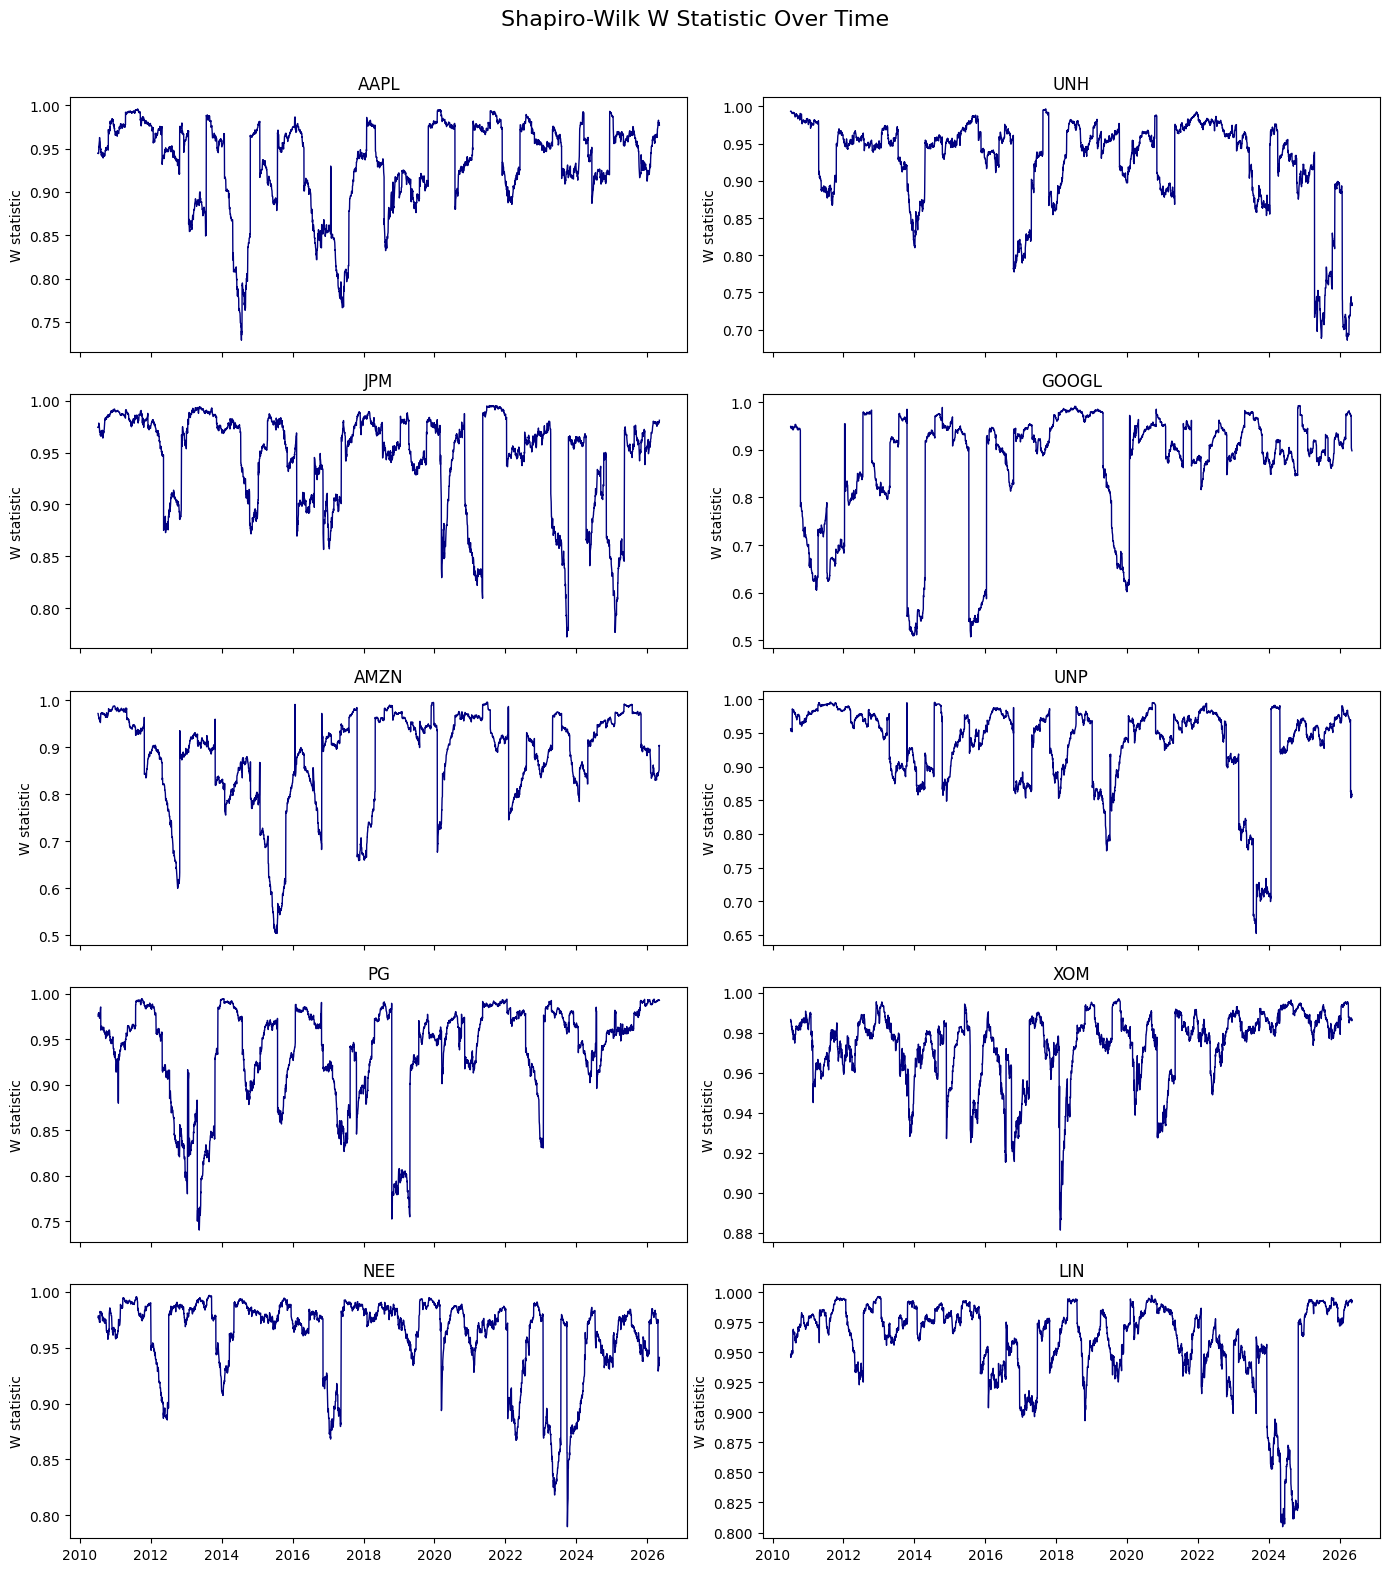

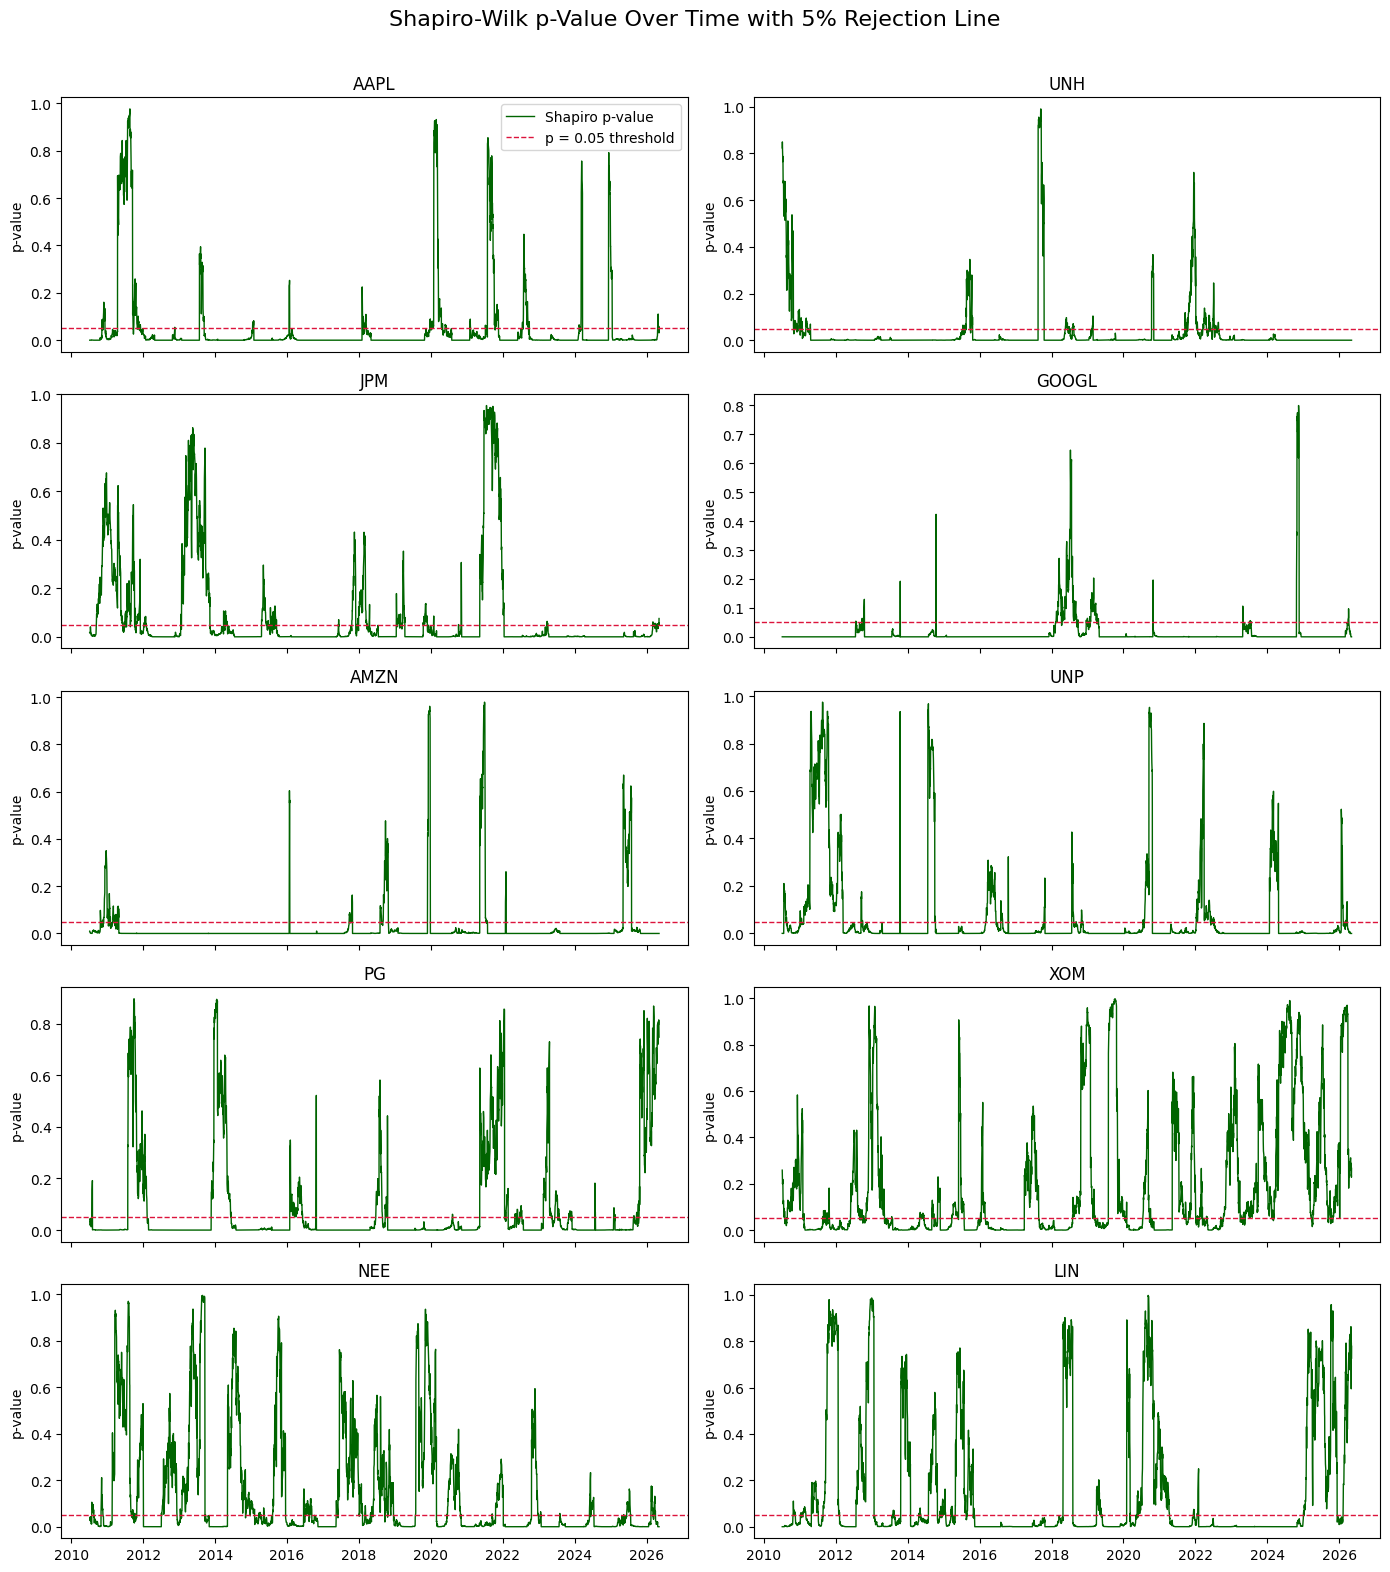

In [14]:
# Plot how the normality test statistics change over time for each stock.
fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
fig.suptitle('Shapiro-Wilk W Statistic Over Time', fontsize=16)
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax = axes[i]
    subset = normality_results[normality_results['Stock'] == stock]
    ax.plot(subset.index, subset['Shapiro_stat'], color='navy', linewidth=1)
    ax.set_title(stock)
    ax.set_ylabel('W statistic')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
fig.suptitle('Shapiro-Wilk p-Value Over Time with 5% Rejection Line', fontsize=16)
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax = axes[i]
    subset = normality_results[normality_results['Stock'] == stock]
    ax.plot(subset.index, subset['Shapiro_p_value'], color='darkgreen', linewidth=1, label='Shapiro p-value')
    ax.axhline(
        y=alpha,
        color='crimson',
        linestyle='--',
        linewidth=1,
        label='p = 0.05 threshold'
    )
    ax.set_title(stock)
    ax.set_ylabel('p-value')
    if i == 0:
        ax.legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
